In [ ]:
import matplotlib.pyplot as plt
import mne
import mne_connectivity
import numpy as np


In [ ]:
connectivity_methods={"plv": "Phase Locking Value (PLV)",
                      "pli": "Phase Lag Index (PLI)",
                      "wpli": "weighted Phase Lag Index (wPLI)"}

def _plot_connectivity_matrix(info, connectivity, freq):
    method = connectivity_methods[connectivity.method]
    data = connectivity.get_data(output="dense")
    freqs = np.asarray(connectivity.freqs)
    freq_idx = np.argmin(np.abs(freq-freqs))
    ch_names = info["ch_names"]
    im = plt.imshow(data[:, :, freq_idx])
    plt.colorbar(im, label=f"{method} [a.u.]")
    plt.xticks(range(0, len(ch_names), 2), ch_names[::2], rotation=45, fontsize=8)
    plt.yticks(range(0, len(ch_names), 2), ch_names[::2], rotation=45, fontsize=8)
    plt.xlabel("Seed channels")
    plt.ylabel("Target channels")
    plt.title(f"{method} at {freq} Hz")

def _plot_connectivity_topo(ch, info, connectivity, freq):
    method = connectivity_methods[connectivity.method]
    freqs = np.asarray(connectivity.freqs)
    freq_idx = np.argmin(np.abs(freq-freqs))
    ch_idx = info["ch_names"].index(ch)
    data = connectivity.get_data(output="dense")
    topo = data[ch_idx, :, freq_idx] + data[:, ch_idx, freq_idx]
    mask = np.zeros(len(info["ch_names"]), dtype=bool)
    mask[ch_idx] = True
    fig, ax = plt.subplots(1,1)
    im, _ = mne.viz.plot_topomap(
        topo, pos=info, axes=ax, mask=mask, names=info["ch_names"], cmap="viridis", show=False, vlim=(topo.min(), topo.max()),
        mask_params=dict(marker='o', markerfacecolor='none', markeredgecolor='r', markersize=15))
    plt.colorbar(im, ax=ax, label=f"{method} [a.u.]")
    fig.suptitle(f"{method} for {ch} at {freq} Hz")
    plt.show()

def _plot_connectivity_per_freq(ch1, ch2, info, connectivity):
    data = connectivity.get_data(output="dense")
    method = connectivity_methods[connectivity.method]
    target_idx = info["ch_names"].index(ch1)
    seed_idx = info["ch_names"].index(ch2)
    if target_idx < seed_idx:
        target_idx, seed_idx = seed_idx, target_idx
    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    topo = np.zeros(data.shape[0])
    mask = np.zeros(len(info["ch_names"]), dtype=bool)
    ch1_idx = info["ch_names"].index(ch1)
    ch2_idx = info["ch_names"].index(ch2)
    mask[ch1_idx] = True
    mask[ch2_idx] = True
    mne.viz.plot_topomap(
        topo, pos=info, axes=ax[0], mask=mask, names=info["ch_names"], show=False,
        mask_params=dict(marker='o', markerfacecolor='none', markeredgecolor='r', markersize=15))
    ax[1].plot(connectivity.freqs, data[target_idx, seed_idx, :])
    ax[1].set(xlabel="Frequency [Hz]", ylabel=f"{method} [a.u.]", ylim=(0,1))
    fig.suptitle(f"{method} between {ch1} and {ch2}")
    plt.show()

def _simulate_sync_signals(n_epochs=40, dur=4, fs=500, freq=10, phase_lag=0,
                           noise_level=0.5, random_phase=False):
    n = int(dur * fs)
    t = np.linspace(0, dur, n)
    rng = np.random.RandomState(42)

    sig1 = np.zeros((n_epochs, n))
    sig2 = np.zeros((n_epochs, n))

    for i in range(n_epochs):
        phi = rng.uniform(0, 2 * np.pi) if random_phase else 0
        sig1[i] = np.sin(2 * np.pi * freq * t + phi) + rng.randn(n) * noise_level
        sig2[i] = np.sin(2 * np.pi * freq * t + phi + phase_lag) + rng.randn(n) * noise_level

    return t, sig1, sig2

def _compute_phase(sig, fs, freq):
    n = sig.shape[1]
    freqs = np.fft.rfftfreq(n, 1 / fs)
    freq_idx = np.argmin(np.abs(freqs - freq))
    phase = np.angle(np.fft.rfft(sig, axis=1)[:, freq_idx])
    return phase

def _plot_phase_distribution(phase):
    bins = np.linspace(-np.pi, np.pi, 25)
    fig, ax = plt.subplots(subplot_kw=dict(projection="polar"))
    counts, edges = np.histogram(phase, bins=bins)
    ax.bar(edges[:-1], counts, width=np.diff(edges), align="edge")

class utils:
    simulate_sync_signals = _simulate_sync_signals
    plot_connectivity_matrix = _plot_connectivity_matrix
    plot_connectivity_per_freq = _plot_connectivity_per_freq
    plot_connectivity_topo = _plot_connectivity_topo
    plot_phase_distribution = _plot_phase_distribution
    compute_phase = _compute_phase

## Extracting and Visualizing Phase Information

The instantaneous phase of a signal describes where it is in its oscillatory cycle at a given moment. For two signals oscillating at the same frequency, the **phase lag** is the angular offset between their cycles.

Phase-based connectivity measures are built on a simple idea: if two brain regions are functionally connected, their oscillations will have a consistent phase relationship across time and trials. If they are not connected, the phase difference between them will be random.

In this section, we use the discrete Fourier transform (DFT) to extract the phase of simulated signals at a specific frequency and visualize the phase distribution across epochs using polar histograms.

| Code | Description |
| --- | --- |
| `utils.simulate_sync_signals(n_epochs, dur, fs, freq, phase_lag, noise_level, random_phase)` | Simulate two signals with a sinusoidal oscillation at `freq` Hz and a fixed `phase_lag` |
| `utils.compute_phase(sig, fs, freq)` | Compute the phase of `sig` at `freq` Hz using the DFT |
| `utils.plot_phase_distribution(phase)` | Plot the distribution of `phase` values in a polar histogram |

The code below generates two signals with a 2 Hz oscillation at a fixed phase lag.

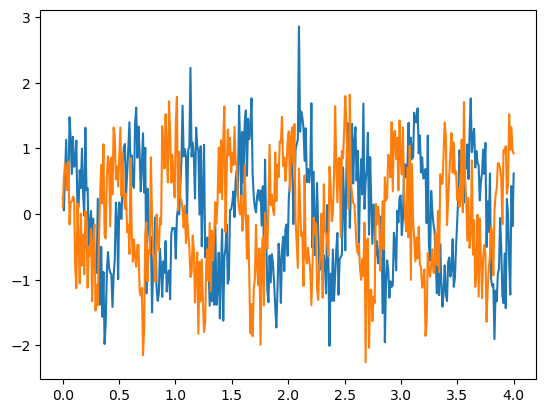

In [132]:
t, sig1, sig2 = utils.simulate_sync_signals(
    dur=4, fs=100, freq=2, phase_lag=2
)
plt.plot(t, sig1[0])
plt.plot(t, sig2[0])

**Example**: Compute the phase of `sig1` at 10 Hz and plot the phase distribution in a polar plot.

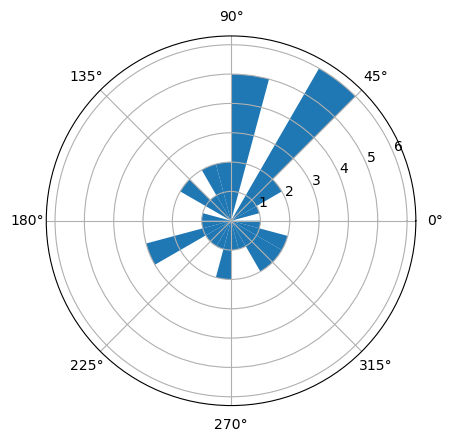

In [133]:
phase = utils.compute_phase(sig1, fs=100, freq=10)
utils.plot_phase_distribution(phase)

**Exercise**: Compute the phase of `sig1` at 2 Hz and plot the phase distribution in a polar plot. What is the phase of the signal?

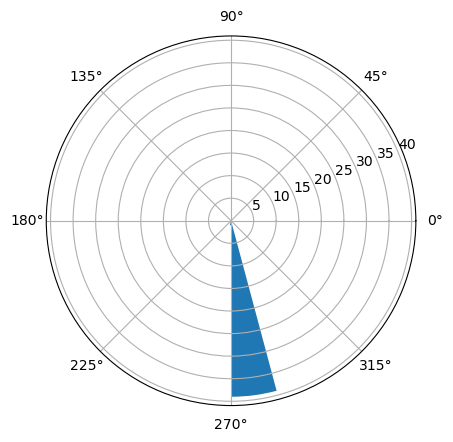

In [134]:
phase = utils.compute_phase(sig1, fs=100, freq=2)
utils.plot_phase_distribution(phase)

**Exercise**: Compute the phase of `sig2` at 2 Hz and plot the phase distribution in a polar plot. What is the phase of the signal?

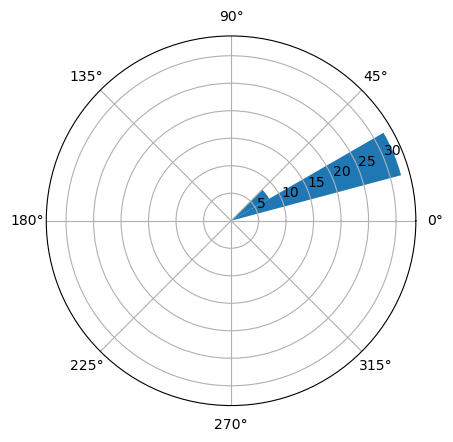

In [135]:
phase = utils.compute_phase(sig2, fs=100, freq=2)
utils.plot_phase_distribution(phase)

Real neural signals do not have a constant phase. Run the cell below to repeat the simulation with a random phase offset for every epoch (while keeping the phase lag between the signals constant).

In [136]:
t, sig1, sig2 = utils.simulate_sync_signals(
    dur=4, fs=100, freq=2, phase_lag=2, random_phase=True
)

**Exercise**: Compute and plot the phase distribution for `sig1` and `sig2` separately at 2 Hz. Do the individual signals still show a dominant phase?

In [ ]:
phase = utils.compute_phase(sig1, fs=100, freq=2)
utils.plot_phase_distribution(phase)

In [ ]:
phase = utils.compute_phase(sig2, fs=100, freq=2)
utils.plot_phase_distribution(phase)

**Example**: Compute the phase difference between `sig1` and `sig2` at 10 Hz and visualize it in a polar plot.

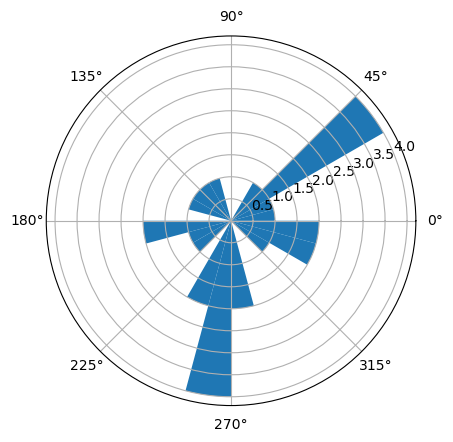

In [137]:
phase1 = utils.compute_phase(sig1, fs=100, freq=10)
phase2 = utils.compute_phase(sig2, fs=100, freq=10)
phase_diff = phase1 - phase2
utils.plot_phase_distribution(phase_diff)


**Exercise**: Compute the phase difference between `sig1` and `sig2` at 2 Hz and visualize it in a polar plot. What is the phase lag between the signals?

Looking at the consistency of the phase difference across epochs is how phase-based connectivity measures work.

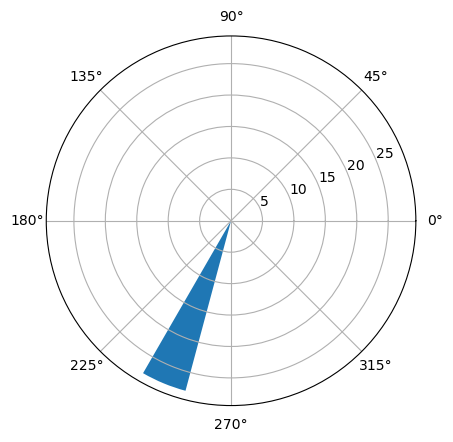

In [138]:
phase1 = utils.compute_phase(sig1, fs=100, freq=2)
phase2 = utils.compute_phase(sig2, fs=100, freq=2)
phase_diff = phase1 - phase2
utils.plot_phase_distribution(phase_diff)

## Phase Lag Value (PLV)

| Code | Description |
| --- | --- |
| `con = mne_connectivity.spectral_connectivity_epochs(epochs)` | Compute the connectivity for all `epochs` |
| `con.get_data(output="dense")` | Get the connectivity matrix with shape channels x channelsx frequencies |
| `utils.plot_connectivity_matrix(info, connectivity, freq)` | Plot the `connectivity` at frequency `freq` for the channels in `info` |
| `utils.plot_connectivity_topo(ch, info, connectivity, freq)` | Create a topoplot for the connectivity between `ch` and every other channel at the frequency `freq` |
| `utils.plot_connectivity_per_freq(ch1, ch2, info, connectivity)` | Plot the connectivity between `ch1` and `ch2` across all frequencies |

**Example**: Estimate the pariwise connectivity for all electrode pairs using the phase lag index `"plv"` method for frequencies up to `fmax=80` Hz. Then, get the connectivity matrix and print its shape - the dimensions are $(channels \times channels \times frequencies)$.

In [ ]:
plv = mne_connectivity.spectral_connectivity_epochs(epochs, method="plv", fmax=80, verbose=False)
data = plv.get_data(output="dense")
data.shape


**Exercise**: Estimate the pariwise connectivity for all electrode pairs using the phase lag index `"plv"` method for frequencies up to `fmax=40` Hz. Then, get the connectivity matrix and print its shape.

In [ ]:
plv = mne_connectivity.spectral_connectivity_epochs(epochs, method="plv", fmax=40, verbose=False)
data = plv.get_data(output="dense")
data.shape


**Example**: Plot the matrix of estimtated connectivity values at `20` Hz.

In [ ]:
freq = 20
utils.plot_connectivity_matrix(info=epochs.info, connectivity=plv, freq=freq)

**Exercise**: Plot the matrix of estimtated connectivity values at `9.3` Hz. How does this look different from the connectivity at 20 Hz?

In [ ]:
freq = 9.3
utils.plot_connectivity_matrix(info=epochs.info, connectivity=plv, freq=freq)

**Exercise**: Plot the matrix of estimtated connectivity values at `8` Hz. Would you expect there to be more or less connectivity compared to 9.3 Hz?

In [ ]:
freq = 8
utils.plot_connectivity_matrix(info=epochs.info, connectivity=plv, freq=freq)

**Example**: Plot the connectivity between `"F7"` (close to the simulates source in Broca's area) and all other electrodes at `8` Hz as a topoplot.

In [ ]:
freq = 8
ch = "F7"
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=plv, freq=freq)


**Exercise**: Plot the connectivity between `"T7"` (close to the source in the primary auditory cortex) and all other electrodes at `8` Hz as a topoplot.

In [ ]:
freq = 8
ch = "T7"
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=plv, freq=freq)

**Exercise**: Plot the connectivity between `"T8"` (close to the right hemisphere's primary auditory cortex) and all other electrodes at `8` Hz as a topoplot.

In [ ]:
freq = 8
ch = "T8"
utils.plot_connectivity_topo(ch, info=epochs.info, connectivity=plv, freq=freq)

**Example**: plot the connectivity between `"T7"` (Broca's area) and `"F7"` (primary auditory cortex) across all frequencies.

In [ ]:
ch1 = "T7"
ch2 = "F7"

utils.plot_connectivity_per_freq(ch1, ch2, info=epochs.info, connectivity=plv)

**Exercise**: plot the connectivity between `"T7"` (Broca's area) and its neighbor `"T9"` across frequencies. Does the high phase locking value here reflect connectivity between actual neural sources?

In [ ]:
ch1 = "T7"
ch2 = "T9"

utils.plot_connectivity_per_freq(ch1, ch2, info=epochs.info, connectivity=plv)

## Phase Lag Based Connectivity

| Code | Description |
| --- | --- |
| `mne.connectivity.spectral_connectivity_epochs(epochs, method="pli")` | Compute the spectral connectivity for all `epochs` using the phase lag index (`"pli"`) method |
| `utils.plot_connectivity_topo(ch, info, connectivity, freq)` | Create a topoplot for the connectivity between `ch` and every other channel at the frequency `freq` |

**Exercise**: Estimate the pariwise connectivity for all electrode pairs using the phase lag index `"pli"` (phase lag index) method.

In [ ]:
pli = mne_connectivity.spectral_connectivity_epochs(epochs, fmax=40, method="pli", verbose=False)

**Exercise**: Plot the connectivity between `"T7"` and all other electrodes at `8` Hz - both for PLV and PLI and compare the two topoplots.

In [ ]:
freq = 8
ch = "T7"
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=plv, freq=freq)
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=pli, freq=freq)

**Exercise**: plot the connectivity between `"T7"` and `"T9"` across frequencies both for PLI and PLV and compare the two plots.

In [ ]:
ch1 = "T7"
ch2 = "T9"

utils.plot_connectivity_per_freq(ch1, ch2, info=epochs.info, connectivity=plv)
utils.plot_connectivity_per_freq(ch1, ch2, info=epochs.info, connectivity=pli)

## Surface Laplacian

In [ ]:
csd = mne.preprocessing.compute_current_source_density(epochs)

In [ ]:
csd.average().crop(0, 0.4).plot_joint();

**Exercise**

In [ ]:
pli_csd = mne_connectivity.spectral_connectivity_epochs(data=csd, fmax=40, method="pli", verbose=False)

**Exercise**

In [ ]:
freq = 8
ch = "T7"
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=pli_csd, freq=freq)

**Exercise**

In [ ]:
freq = 8
ch = "F7"
utils.plot_connectivity_topo(ch=ch, info=epochs.info, connectivity=pli_csd, freq=freq)

## Time-resolved Connectivity.